Training Images Shape: (300, 256, 256, 3)
Training Masks Shape: (300, 256, 256)
Validation Images Shape: (60, 256, 256, 3)
Validation Masks Shape: (60, 256, 256)
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d_57 (Conv2D)          (None, 256, 256, 32)         896       ['input_4[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 32)         128       ['conv2d_57[0][0]']           
 Normalization)                                                                                   
                             

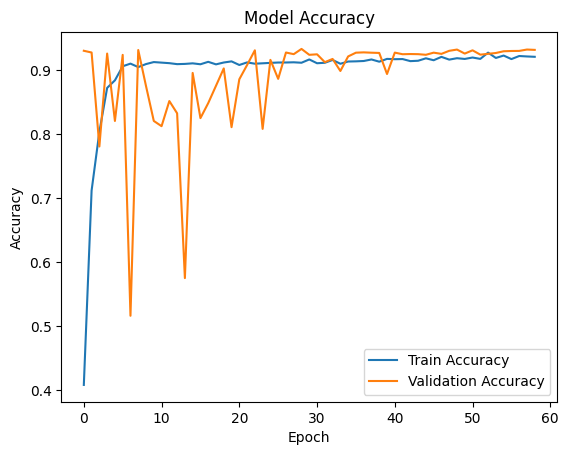

In [ ]:
# Cell 1: Import Libraries
import numpy as np
import os
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Cell 2: Load and Preprocess Data
def load_data(image_dirs, mask_dirs):
    images = []
    masks = []

    for img_dir, mask_dir in zip(image_dirs, mask_dirs):
        for img_name in os.listdir(img_dir):
            img_path = os.path.join(img_dir, img_name)
            mask_path = os.path.join(mask_dir, img_name.replace('.jpg', '.xml'))  # Adjust if your mask format differs

            # Read image
            image = cv2.imread(img_path)
            image = cv2.resize(image, (256, 256))
            images.append(image)

            # Read mask
            mask = np.zeros((256, 256, 4))  # Assuming 4 classes (RBC, WBC, Platelets, Background)
            tree = ET.parse(mask_path)
            root = tree.getroot()

            # Parse XML and fill mask array
            for obj in root.findall('object'):
                class_id = obj.find('name').text
                points = obj.find('bndbox')
                x_min = int(points.find('xmin').text)
                y_min = int(points.find('ymin').text)
                x_max = int(points.find('xmax').text)
                y_max = int(points.find('ymax').text)

                if class_id == 'RBC':
                    mask[y_min:y_max, x_min:x_max, 0] = 1  # Channel for RBC
                elif class_id == 'WBC':
                    mask[y_min:y_max, x_min:x_max, 1] = 1  # Channel for WBC
                elif class_id == 'Platelet':
                    mask[y_min:y_max, x_min:x_max, 2] = 1  # Channel for Platelet
                else:
                    mask[y_min:y_max, x_min:x_max, 3] = 1  # Background

            masks.append(mask)

    return np.array(images), np.array(masks)

# Define your directories
train_image_dirs = ['/content/drive/MyDrive/train/images']
train_mask_dirs = ['/content/drive/MyDrive/train/annotations']
val_image_dirs = ['/content/drive/MyDrive/val/images']
val_mask_dirs = ['/content/drive/MyDrive/val/annotations']

# Load Data
train_images, train_masks = load_data(train_image_dirs, train_mask_dirs)
val_images, val_masks = load_data(val_image_dirs, val_mask_dirs)

# Normalize images
train_images = train_images / 255.0
val_images = val_images / 255.0

# Normalize masks (one-hot encoding)
train_masks = np.argmax(train_masks, axis=-1)
val_masks = np.argmax(val_masks, axis=-1)

print("Training Images Shape:", train_images.shape)
print("Training Masks Shape:", train_masks.shape)
print("Validation Images Shape:", val_images.shape)
print("Validation Masks Shape:", val_masks.shape)

# Cell 3: Create Data Generators with Augmentation
train_gen = ImageDataGenerator(rotation_range=30, width_shift_range=0.1, height_shift_range=0.1,
                                shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')

val_gen = ImageDataGenerator()

train_gen = train_gen.flow(train_images, train_masks, batch_size=14)
val_gen = val_gen.flow(val_images, val_masks, batch_size=14)

# Cell 4: Build U-Net Model with Batch Normalization
def unet_model(input_size=(256, 256, 3)):
    inputs = layers.Input(input_size)

    # Downsampling
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)
    c4 = layers.BatchNormalization()(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c5)
    c5 = layers.BatchNormalization()(c5)

    # Upsampling
    u6 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c6)
    c6 = layers.BatchNormalization()(c6)

    u7 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c7)
    c7 = layers.BatchNormalization()(c7)

    u8 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c8)
    c8 = layers.BatchNormalization()(c8)

    u9 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.BatchNormalization()(c9)
    c9 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c9)
    c9 = layers.BatchNormalization()(c9)

    outputs = layers.Conv2D(4, (1, 1), activation='softmax')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Build model
model = unet_model()
model.summary()

# Cell 5: Train Model with Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(train_gen, validation_data=val_gen,
                    steps_per_epoch=len(train_images) // 14,
                    validation_steps=len(val_images) // 14,
                    epochs=100,
                    callbacks=[reduce_lr, early_stopping])

# Cell 6: Evaluate Model
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Cell 7: Predict on New Images
def predict_and_visualize(model, image_paths):
    for img_path in image_paths:
        image = cv2.imread(img_path)
        image_resized = cv2.resize(image, (256, 256)) / 255.0
        image_input = np.expand_dims(image_resized, axis=0)

        prediction = model.predict(image_input)
        predicted_mask = np.argmax(prediction, axis=-1).reshape(256, 256)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title('Original Image')
        plt.imshow(image)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Predicted Mask')
        plt.imshow(predicted_mask, cmap='jet', alpha=0.5)
        plt.axis('off')
        plt.show()

# Example usage:
# predict_and_visualize(model, ['/path/to/new/image.jpg'])

In [ ]:
model.save('/content/drive/MyDrive/Model.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/5 [==============================] - 2s 391ms/step - loss: 0.1933 - accuracy: 0.9283
Validation Loss: 0.19326423108577728
Validation Accuracy: 0.9282880425453186


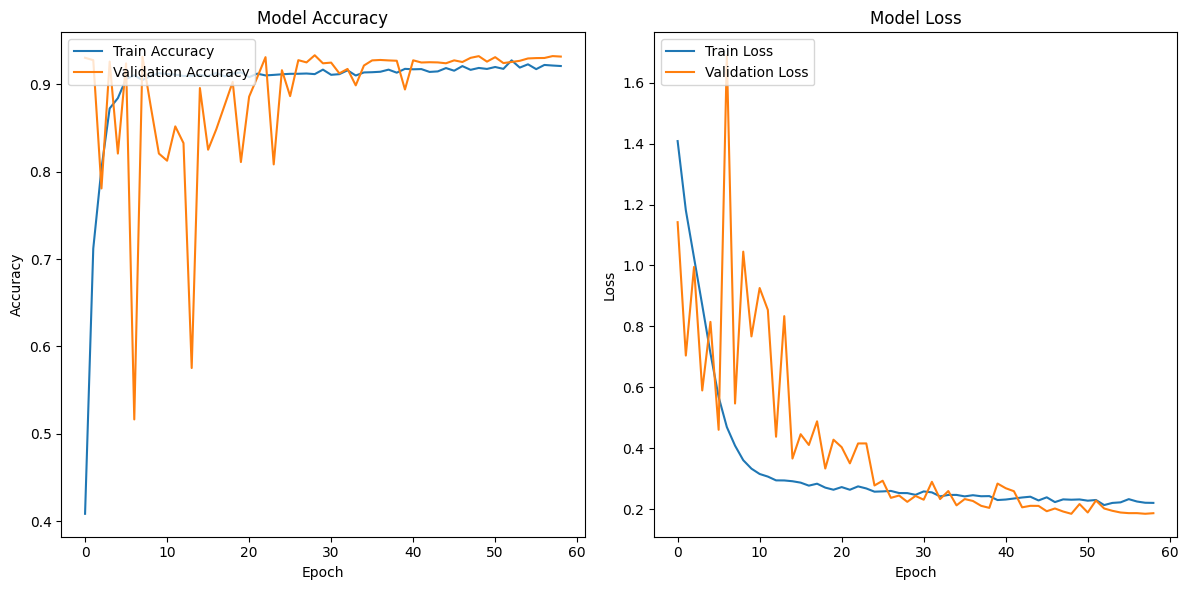

In [ ]:
# After training your model
# Cell 8: Evaluate the Model
val_loss, val_accuracy = model.evaluate(val_gen)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

# Cell 9: Plot Training History
import matplotlib.pyplot as plt

# Assuming 'history' is the result of your model.fit
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 447ms/step
Predicted class probabilities at center pixel: [0.9428252  0.04649632 0.00492297 0.00575559]
Unique values in predicted mask after thresholding: [0 1 2]
RBC Count: 19
WBC Count: 1
Platelet Count: 0


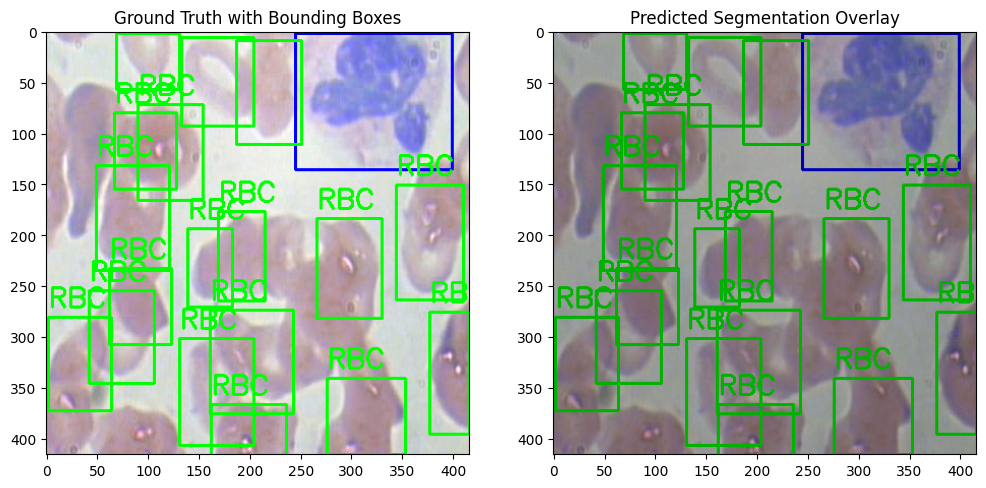

In [ ]:
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# Load the model
model = load_model('/content/drive/MyDrive/Model.h5')

def preprocess_image(image, target_size=(256, 256)):
    """Resize and normalize the image for U-Net input."""
    resized_image = cv2.resize(image, target_size)
    resized_image = resized_image / 255.0  # Normalize to [0, 1]
    resized_image = np.expand_dims(resized_image, axis=0)
    return resized_image

def count_cells(mask, class_id):
    """Count the number of cells in the predicted mask."""
    unique, counts = np.unique(mask, return_counts=True)
    count_dict = dict(zip(unique, counts))
    return count_dict.get(class_id, 0)

def predict_and_visualize(image_path, xml_file=None):
    # Load and preprocess the image
    image = cv2.imread(image_path)
    input_image = preprocess_image(image, target_size=(256, 256))  # Resize and preprocess

    # Make predictions
    predictions = model.predict(input_image)[0]

    # Debug: Check the predicted probabilities for each class at a specific pixel (e.g., center pixel)
    print(f"Predicted class probabilities at center pixel: {predictions[128, 128, :]}")

    # Use a threshold instead of argmax to detect low-probability WBCs/Platelets
    threshold_rbc = 0.6
    threshold_wbc = 0.2
    threshold_platelet = 0.3
    predicted_mask = np.zeros(predictions.shape[:2], dtype=np.uint8)
    predicted_mask[predictions[:, :, 1] > threshold_rbc] = 1  # RBCs
    predicted_mask[predictions[:, :, 2] > threshold_wbc] = 2  # WBCs
    predicted_mask[predictions[:, :, 3] > threshold_platelet] = 3  # Platelets

    # Debug: Check unique values in predicted mask after thresholding
    print(f"Unique values in predicted mask after thresholding: {np.unique(predicted_mask)}")

    # Resize predicted mask back to original image size
    predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.shape[1], image.shape[0]))

    # Count the number of RBCs, WBCs, and Platelets
    rbc_count = count_cells(predicted_mask_resized, class_id=1)
    wbc_count = count_cells(predicted_mask_resized, class_id=2)
    platelet_count = count_cells(predicted_mask_resized, class_id=3)

    print(f"RBC Count: {rbc_count}")
    print(f"WBC Count: {wbc_count}")
    print(f"Platelet Count: {platelet_count}")

    # Load the XML file for ground truth if provided
    ground_truth_boxes = []
    if xml_file is not None:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Extract bounding boxes and labels from XML
        for obj in root.findall('object'):
            label = obj.find('name').text
            xmin = int(obj.find('bndbox/xmin').text)
            ymin = int(obj.find('bndbox/ymin').text)
            xmax = int(obj.find('bndbox/xmax').text)
            ymax = int(obj.find('bndbox/ymax').text)
            ground_truth_boxes.append((label, xmin, ymin, xmax, ymax))

    # Visualize the results
    visualize_results(image, predicted_mask_resized, ground_truth_boxes)

def visualize_results(image, predicted_mask, ground_truth_boxes):
    image_copy = image.copy()

    # Draw the ground truth bounding boxes
    for box in ground_truth_boxes:
        label, xmin, ymin, xmax, ymax = box
        color = (0, 255, 0) if label == 'RBC' else (255, 0, 0) if label == 'WBC' else (0, 0, 255)  # Assign color
        cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(image_copy, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Overlay predicted masks on the original image
    mask_overlay = np.zeros_like(image)
    mask_overlay[predicted_mask == 1] = [255, 0, 0]  # RBC
    mask_overlay[predicted_mask == 2] = [0, 255, 0]  # WBC
    mask_overlay[predicted_mask == 3] = [0, 0, 255]  # Platelets

    blended = cv2.addWeighted(image_copy, 0.7, mask_overlay, 0.3, 0)

    # Display the original image, ground truth, and predicted segmentation
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Ground Truth with Bounding Boxes')
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 2, 2)
    plt.title('Predicted Segmentation Overlay')
    plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))

    plt.show()

# Example usage
image_path = '/content/BloodImage_00001_jpg.rf.1a3206b15602db1d97193162a50bd001.jpg'
xml_file = '/content/BloodImage_00001_jpg.rf.1a3206b15602db1d97193162a50bd001.xml'  # Optional, set to None if not available
predict_and_visualize(image_path, xml_file)


1/1 [==============================] - 0s 441ms/step
Predicted class probabilities at center pixel: [0.91930604 0.0647535  0.00803891 0.00790143]
Optimal thresholds: {'RBC': 0.49306757450103744, 'WBC': 0.010101580806076526, 'Platelets': 0.01157122403383255}
Unique values in predicted mask after thresholding: [0 1 2 3]
RBC Count: 10
WBC Count: 1
Platelet Count: 2


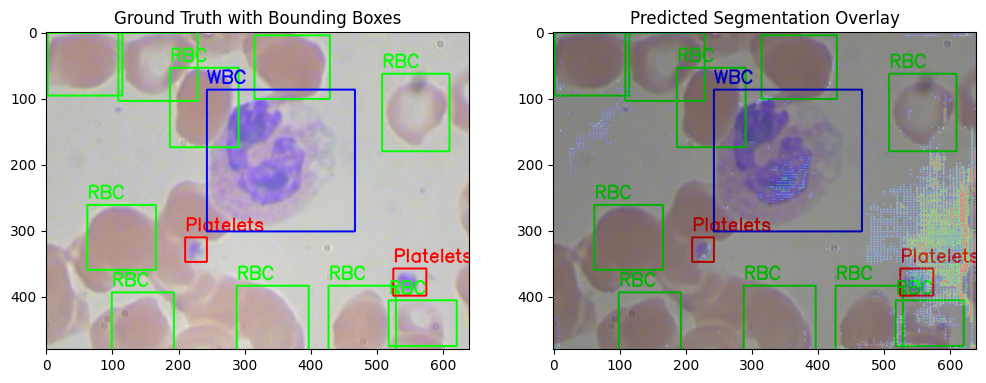

In [ ]:
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# Load the model
model = load_model('/content/drive/MyDrive/Model.h5')

def preprocess_image(image, target_size=(256, 256)):
    """Resize and normalize the image for U-Net input."""
    resized_image = cv2.resize(image, target_size)
    resized_image = resized_image / 255.0  # Normalize to [0, 1]
    resized_image = np.expand_dims(resized_image, axis=0)
    return resized_image

def count_cells(mask, class_id, min_size=50):
    """Count distinct cells in the predicted mask using connected components."""
    # Create a binary mask for the specific class
    binary_mask = np.zeros_like(mask, dtype=np.uint8)
    binary_mask[mask == class_id] = 255  # Set the class ID area to 255

    # Count connected components
    num_labels, labels = cv2.connectedComponents(binary_mask)

    # Filter by size
    sizes = np.bincount(labels.ravel())
    filtered_count = np.sum(sizes[1:] >= min_size)  # Ignore the background label (0)

    return filtered_count

def get_optimal_thresholds(predictions):
    """Calculate optimal thresholds based on percentiles with adjustments."""
    thresholds = {}
    thresholds['RBC'] = np.percentile(predictions[:, :, 1], 96)  # Increased for RBCs
    thresholds['WBC'] = np.percentile(predictions[:, :, 2], 96)  # Increased for WBCs
    thresholds['Platelets'] = np.percentile(predictions[:, :, 3], 96)  # Increased for Platelets
    return thresholds

def predict_and_visualize(image_path, xml_file=None):
    # Load and preprocess the image
    image = cv2.imread(image_path)
    input_image = preprocess_image(image, target_size=(256, 256))  # Resize and preprocess

    # Make predictions
    predictions = model.predict(input_image)[0]

    # Debug: Check the predicted probabilities for each class at a specific pixel (e.g., center pixel)
    print(f"Predicted class probabilities at center pixel: {predictions[128, 128, :]}")

    # Automatically determine optimal thresholds based on predicted probabilities
    thresholds = get_optimal_thresholds(predictions)
    print(f"Optimal thresholds: {thresholds}")

    predicted_mask = np.zeros(predictions.shape[:2], dtype=np.uint8)
    predicted_mask[predictions[:, :, 1] > thresholds['RBC']] = 1  # RBCs
    predicted_mask[predictions[:, :, 2] > thresholds['WBC']] = 2  # WBCs
    predicted_mask[predictions[:, :, 3] > thresholds['Platelets']] = 3  # Platelets

    # Debug: Check unique values in predicted mask after thresholding
    print(f"Unique values in predicted mask after thresholding: {np.unique(predicted_mask)}")

    # Resize predicted mask back to original image size
    predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.shape[1], image.shape[0]))

   # Count the number of RBCs, WBCs, and Platelets
   # When calling count_cells, increase min_size if needed
    rbc_count = count_cells(predicted_mask_resized, class_id=1, min_size=130)  # Further increased
    wbc_count = count_cells(predicted_mask_resized, class_id=2, min_size=500)  # Further increased
    platelet_count = count_cells(predicted_mask_resized, class_id=3, min_size=200)  # Further increased

    print(f"RBC Count: {rbc_count}")
    print(f"WBC Count: {wbc_count}")
    print(f"Platelet Count: {platelet_count}")

    # Load the XML file for ground truth if provided
    ground_truth_boxes = []
    if xml_file is not None:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Extract bounding boxes and labels from XML
        for obj in root.findall('object'):
            label = obj.find('name').text
            xmin = int(obj.find('bndbox/xmin').text)
            ymin = int(obj.find('bndbox/ymin').text)
            xmax = int(obj.find('bndbox/xmax').text)
            ymax = int(obj.find('bndbox/ymax').text)
            ground_truth_boxes.append((label, xmin, ymin, xmax, ymax))

    # Visualize the results
    visualize_results(image, predicted_mask_resized, ground_truth_boxes)

def visualize_results(image, predicted_mask, ground_truth_boxes):
    image_copy = image.copy()

    # Draw the ground truth bounding boxes
    for box in ground_truth_boxes:
        label, xmin, ymin, xmax, ymax = box
        color = (0, 255, 0) if label == 'RBC' else (255, 0, 0) if label == 'WBC' else (0, 0, 255)  # Assign color
        cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(image_copy, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Overlay predicted masks on the original image
    mask_overlay = np.zeros_like(image)
    mask_overlay[predicted_mask == 1] = [255, 0, 0]  # RBC
    mask_overlay[predicted_mask == 2] = [0, 255, 0]  # WBC
    mask_overlay[predicted_mask == 3] = [0, 0, 255]  # Platelets

    blended = cv2.addWeighted(image_copy, 0.7, mask_overlay, 0.3, 0)

    # Display the original image, ground truth, and predicted segmentation
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Ground Truth with Bounding Boxes')
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 2, 2)
    plt.title('Predicted Segmentation Overlay')
    plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))

    plt.show()

# Example usage
image_path = '/content/BloodImage_00117_jpg.rf.b35d5c3f818b6732815da9fb1a3bffa1.jpg'
xml_file = '/content/BloodImage_00117_jpg.rf.b35d5c3f818b6732815da9fb1a3bffa1.xml'  # Optional, set to None if not available
predict_and_visualize(image_path, xml_file)


1/1 [==============================] - 1s 1s/step
Predicted class probabilities at center pixel: [0.9425701  0.04485537 0.00538661 0.00718792]
Optimal thresholds: {'RBC': 0.4080419778823852, 'WBC': 0.009388838335871695, 'Platelets': 0.010545374080538749}
Unique values in predicted mask after thresholding: [0 1 2 3]
RBC Count: 5
WBC Count: 2
Platelet Count: 3


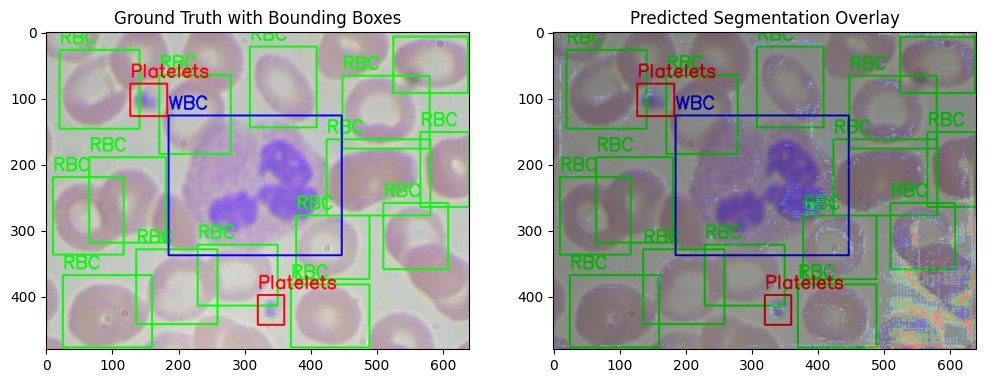

In [ ]:
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# Load the model
model = load_model('/content/drive/MyDrive/Model.h5')

def preprocess_image(image, target_size=(256, 256)):
    """Resize and normalize the image for U-Net input."""
    resized_image = cv2.resize(image, target_size)
    resized_image = resized_image / 255.0  # Normalize to [0, 1]
    resized_image = np.expand_dims(resized_image, axis=0)
    return resized_image

def count_cells(mask, class_id, min_size=50):
    """Count distinct cells in the predicted mask using connected components."""
    # Create a binary mask for the specific class
    binary_mask = np.zeros_like(mask, dtype=np.uint8)
    binary_mask[mask == class_id] = 255  # Set the class ID area to 255

    # Count connected components
    num_labels, labels = cv2.connectedComponents(binary_mask)

    # Filter by size
    sizes = np.bincount(labels.ravel())
    filtered_count = np.sum(sizes[1:] >= min_size)  # Ignore the background label (0)

    return filtered_count

def get_optimal_thresholds(predictions):
    """Calculate optimal thresholds based on percentiles with adjustments."""
    thresholds = {}
    thresholds['RBC'] = np.percentile(predictions[:, :, 1], 96)  # Increased for RBCs
    thresholds['WBC'] = np.percentile(predictions[:, :, 2], 96)  # Increased for WBCs
    thresholds['Platelets'] = np.percentile(predictions[:, :, 3], 96)  # Increased for Platelets
    return thresholds

def predict_and_visualize(image_path, xml_file=None):
    # Load and preprocess the image
    image = cv2.imread(image_path)
    input_image = preprocess_image(image, target_size=(256, 256))  # Resize and preprocess

    # Make predictions
    predictions = model.predict(input_image)[0]

    # Debug: Check the predicted probabilities for each class at a specific pixel (e.g., center pixel)
    print(f"Predicted class probabilities at center pixel: {predictions[128, 128, :]}")

    # Automatically determine optimal thresholds based on predicted probabilities
    thresholds = get_optimal_thresholds(predictions)
    print(f"Optimal thresholds: {thresholds}")

    predicted_mask = np.zeros(predictions.shape[:2], dtype=np.uint8)
    predicted_mask[predictions[:, :, 1] > thresholds['RBC']] = 1  # RBCs
    predicted_mask[predictions[:, :, 2] > thresholds['WBC']] = 2  # WBCs
    predicted_mask[predictions[:, :, 3] > thresholds['Platelets']] = 3  # Platelets

    # Debug: Check unique values in predicted mask after thresholding
    print(f"Unique values in predicted mask after thresholding: {np.unique(predicted_mask)}")

    # Resize predicted mask back to original image size
    predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.shape[1], image.shape[0]))

   # Count the number of RBCs, WBCs, and Platelets
   # When calling count_cells, increase min_size if needed
    rbc_count = count_cells(predicted_mask_resized, class_id=1, min_size=130)  # Further increased
    wbc_count = count_cells(predicted_mask_resized, class_id=2, min_size=500)  # Further increased
    platelet_count = count_cells(predicted_mask_resized, class_id=3, min_size=200)  # Further increased

    print(f"RBC Count: {rbc_count}")
    print(f"WBC Count: {wbc_count}")
    print(f"Platelet Count: {platelet_count}")

    # Load the XML file for ground truth if provided
    ground_truth_boxes = []
    if xml_file is not None:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Extract bounding boxes and labels from XML
        for obj in root.findall('object'):
            label = obj.find('name').text
            xmin = int(obj.find('bndbox/xmin').text)
            ymin = int(obj.find('bndbox/ymin').text)
            xmax = int(obj.find('bndbox/xmax').text)
            ymax = int(obj.find('bndbox/ymax').text)
            ground_truth_boxes.append((label, xmin, ymin, xmax, ymax))

    # Visualize the results
    visualize_results(image, predicted_mask_resized, ground_truth_boxes)

def visualize_results(image, predicted_mask, ground_truth_boxes):
    image_copy = image.copy()

    # Draw the ground truth bounding boxes
    for box in ground_truth_boxes:
        label, xmin, ymin, xmax, ymax = box
        color = (0, 255, 0) if label == 'RBC' else (255, 0, 0) if label == 'WBC' else (0, 0, 255)  # Assign color
        cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(image_copy, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Overlay predicted masks on the original image
    mask_overlay = np.zeros_like(image)
    mask_overlay[predicted_mask == 1] = [255, 0, 0]  # RBC
    mask_overlay[predicted_mask == 2] = [0, 255, 0]  # WBC
    mask_overlay[predicted_mask == 3] = [0, 0, 255]  # Platelets

    blended = cv2.addWeighted(image_copy, 0.7, mask_overlay, 0.3, 0)

    # Display the original image, ground truth, and predicted segmentation
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Ground Truth with Bounding Boxes')
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 2, 2)
    plt.title('Predicted Segmentation Overlay')
    plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))

    plt.show()

# Example usage
image_path = '/content/BloodImage_00339.jpg'
xml_file = '/content/BloodImage_00339.xml'  # Optional, set to None if not available
predict_and_visualize(image_path, xml_file)


1/1 [==============================] - 1s 1s/step
Calculated thresholds for this image: {'RBC': 0.2760476529598236, 'WBC': 0.010208325646817683, 'Platelets': 0.009795148856937884}
RBC Count: 11
WBC Count: 2
Platelet Count: 3


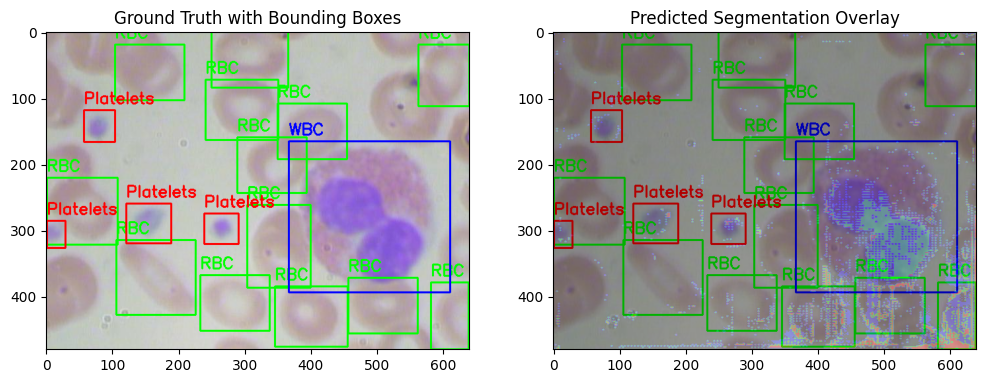

In [ ]:
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# Load the pre-trained model
model = load_model('/content/drive/MyDrive/Model.h5')

def preprocess_image(image, target_size=(256, 256)):
    """Resize and normalize the image for U-Net input."""
    resized_image = cv2.resize(image, target_size)
    resized_image = resized_image / 255.0  # Normalize to [0, 1]
    resized_image = np.expand_dims(resized_image, axis=0)
    return resized_image

def count_cells(mask, class_id, min_size=50):
    """Count distinct cells in the predicted mask using connected components."""
    binary_mask = np.zeros_like(mask, dtype=np.uint8)
    binary_mask[mask == class_id] = 255  # Isolate the specific class

    # Count connected components
    num_labels, labels = cv2.connectedComponents(binary_mask)

    # Filter out small components based on min_size
    sizes = np.bincount(labels.ravel())
    filtered_count = np.sum(sizes[1:] >= min_size)  # Ignore background (label 0)
    return filtered_count

def get_dynamic_thresholds(predictions, class_channel_ids):
    """
    Dynamically calculate thresholds for each class based on image-specific predicted values.

    Args:
        predictions (np.ndarray): The prediction probabilities from the model.
        class_channel_ids (dict): Mapping of class names to their respective channels.

    Returns:
        dict: Class-specific thresholds.
    """
    thresholds = {}
    for class_name, channel_id in class_channel_ids.items():
        # Calculate threshold dynamically based on non-zero probabilities
        class_probs = predictions[:, :, channel_id].flatten()
        non_zero_probs = class_probs[class_probs > 0]  # Exclude zero probabilities
        if len(non_zero_probs) > 0:
            thresholds[class_name] = np.percentile(non_zero_probs, 96)
        else:
            thresholds[class_name] = 0.5  # Default fallback threshold
    return thresholds

def predict_and_visualize(image_path, xml_file=None):
    # Load and preprocess the image
    image = cv2.imread(image_path)
    input_image = preprocess_image(image, target_size=(256, 256))

    # Make predictions
    predictions = model.predict(input_image)[0]

    # Map class names to their channel indices
    class_channel_ids = {'RBC': 1, 'WBC': 2, 'Platelets': 3}

    # Dynamically calculate thresholds for each image
    thresholds = get_dynamic_thresholds(predictions, class_channel_ids)
    print(f"Calculated thresholds for this image: {thresholds}")

    # Generate predicted mask based on dynamic thresholds
    predicted_mask = np.zeros(predictions.shape[:2], dtype=np.uint8)
    for class_name, channel_id in class_channel_ids.items():
        predicted_mask[predictions[:, :, channel_id] > thresholds[class_name]] = channel_id

    # Resize mask to original image dimensions
    predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.shape[1], image.shape[0]))

    # Count cells
    rbc_count = count_cells(predicted_mask_resized, class_id=1, min_size=130)
    wbc_count = count_cells(predicted_mask_resized, class_id=2, min_size=500)
    platelet_count = count_cells(predicted_mask_resized, class_id=3, min_size=200)

    print(f"RBC Count: {rbc_count}")
    print(f"WBC Count: {wbc_count}")
    print(f"Platelet Count: {platelet_count}")

    # Load XML for ground truth bounding boxes (if available)
    ground_truth_boxes = []
    if xml_file:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        for obj in root.findall('object'):
            label = obj.find('name').text
            xmin = int(obj.find('bndbox/xmin').text)
            ymin = int(obj.find('bndbox/ymin').text)
            xmax = int(obj.find('bndbox/xmax').text)
            ymax = int(obj.find('bndbox/ymax').text)
            ground_truth_boxes.append((label, xmin, ymin, xmax, ymax))

    # Visualize the results
    visualize_results(image, predicted_mask_resized, ground_truth_boxes)

def visualize_results(image, predicted_mask, ground_truth_boxes):
    """Overlay predicted masks and ground truth bounding boxes on the original image."""
    image_copy = image.copy()

    # Draw ground truth bounding boxes
    for box in ground_truth_boxes:
        label, xmin, ymin, xmax, ymax = box
        color = (0, 255, 0) if label == 'RBC' else (255, 0, 0) if label == 'WBC' else (0, 0, 255)
        cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(image_copy, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Overlay predicted mask
    mask_overlay = np.zeros_like(image)
    mask_overlay[predicted_mask == 1] = [255, 0, 0]  # RBCs
    mask_overlay[predicted_mask == 2] = [0, 255, 0]  # WBCs
    mask_overlay[predicted_mask == 3] = [0, 0, 255]  # Platelets
    blended = cv2.addWeighted(image_copy, 0.7, mask_overlay, 0.3, 0)

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Ground Truth with Bounding Boxes')
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 2, 2)
    plt.title('Predicted Segmentation Overlay')
    plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    plt.show()

# Example usage
image_path = '/content/BloodImage_00410.jpg'
xml_file = '/content/BloodImage_00410.xml'  # Optional
predict_and_visualize(image_path, xml_file)


1/1 [==============================] - 1s 996ms/step
Calculated thresholds for this image: {'RBC': 0.6211623072624204, 'WBC': 0.01027497872710228, 'Platelets': 0.011758074350655078}
RBC Count: 9
WBC Count: 2
Platelet Count: 3


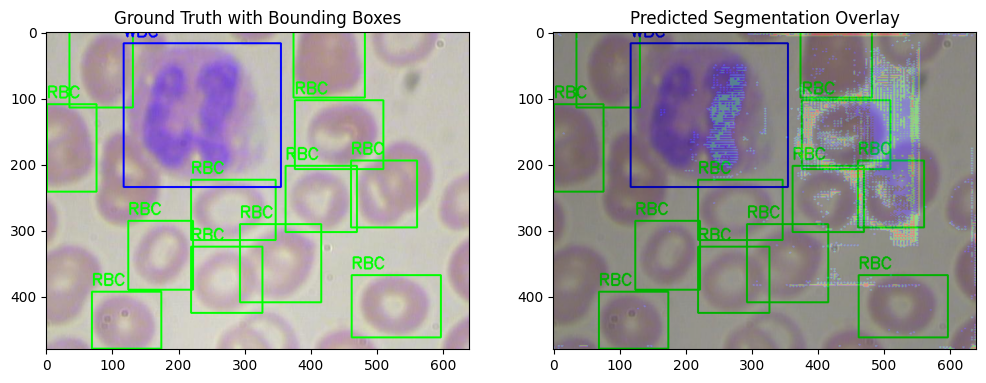

In [ ]:
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# Load the pre-trained model
model = load_model('/content/drive/MyDrive/Model.h5')

def preprocess_image(image, target_size=(256, 256)):
    """Resize and normalize the image for U-Net input."""
    resized_image = cv2.resize(image, target_size)
    resized_image = resized_image / 255.0  # Normalize to [0, 1]
    resized_image = np.expand_dims(resized_image, axis=0)
    return resized_image

def count_cells(mask, class_id, min_size=50):
    """Count distinct cells in the predicted mask using connected components."""
    binary_mask = np.zeros_like(mask, dtype=np.uint8)
    binary_mask[mask == class_id] = 255  # Isolate the specific class

    # Count connected components
    num_labels, labels = cv2.connectedComponents(binary_mask)

    # Filter out small components based on min_size
    sizes = np.bincount(labels.ravel())
    filtered_count = np.sum(sizes[1:] >= min_size)  # Ignore background (label 0)
    return filtered_count

def get_dynamic_thresholds(predictions, class_channel_ids):
    """
    Dynamically calculate thresholds for each class based on image-specific predicted values.

    Args:
        predictions (np.ndarray): The prediction probabilities from the model.
        class_channel_ids (dict): Mapping of class names to their respective channels.

    Returns:
        dict: Class-specific thresholds.
    """
    thresholds = {}
    for class_name, channel_id in class_channel_ids.items():
        # Calculate threshold dynamically based on non-zero probabilities
        class_probs = predictions[:, :, channel_id].flatten()
        non_zero_probs = class_probs[class_probs > 0]  # Exclude zero probabilities
        if len(non_zero_probs) > 0:
            thresholds[class_name] = np.percentile(non_zero_probs, 96)
        else:
            thresholds[class_name] = 0.5  # Default fallback threshold
    return thresholds

def predict_and_visualize(image_path, xml_file=None):
    # Load and preprocess the image
    image = cv2.imread(image_path)
    input_image = preprocess_image(image, target_size=(256, 256))

    # Make predictions
    predictions = model.predict(input_image)[0]

    # Map class names to their channel indices
    class_channel_ids = {'RBC': 1, 'WBC': 2, 'Platelets': 3}

    # Dynamically calculate thresholds for each image
    thresholds = get_dynamic_thresholds(predictions, class_channel_ids)
    print(f"Calculated thresholds for this image: {thresholds}")

    # Generate predicted mask based on dynamic thresholds
    predicted_mask = np.zeros(predictions.shape[:2], dtype=np.uint8)
    for class_name, channel_id in class_channel_ids.items():
        predicted_mask[predictions[:, :, channel_id] > thresholds[class_name]] = channel_id

    # Resize mask to original image dimensions
    predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.shape[1], image.shape[0]))

    # Count cells
    rbc_count = count_cells(predicted_mask_resized, class_id=1, min_size=130)
    wbc_count = count_cells(predicted_mask_resized, class_id=2, min_size=500)
    platelet_count = count_cells(predicted_mask_resized, class_id=3, min_size=200)

    print(f"RBC Count: {rbc_count}")
    print(f"WBC Count: {wbc_count}")
    print(f"Platelet Count: {platelet_count}")

    # Load XML for ground truth bounding boxes (if available)
    ground_truth_boxes = []
    if xml_file:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        for obj in root.findall('object'):
            label = obj.find('name').text
            xmin = int(obj.find('bndbox/xmin').text)
            ymin = int(obj.find('bndbox/ymin').text)
            xmax = int(obj.find('bndbox/xmax').text)
            ymax = int(obj.find('bndbox/ymax').text)
            ground_truth_boxes.append((label, xmin, ymin, xmax, ymax))

    # Visualize the results
    visualize_results(image, predicted_mask_resized, ground_truth_boxes)

def visualize_results(image, predicted_mask, ground_truth_boxes):
    """Overlay predicted masks and ground truth bounding boxes on the original image."""
    image_copy = image.copy()

    # Draw ground truth bounding boxes
    for box in ground_truth_boxes:
        label, xmin, ymin, xmax, ymax = box
        color = (0, 255, 0) if label == 'RBC' else (255, 0, 0) if label == 'WBC' else (0, 0, 255)
        cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(image_copy, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Overlay predicted mask
    mask_overlay = np.zeros_like(image)
    mask_overlay[predicted_mask == 1] = [255, 0, 0]  # RBCs
    mask_overlay[predicted_mask == 2] = [0, 255, 0]  # WBCs
    mask_overlay[predicted_mask == 3] = [0, 0, 255]  # Platelets
    blended = cv2.addWeighted(image_copy, 0.7, mask_overlay, 0.3, 0)

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Ground Truth with Bounding Boxes')
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 2, 2)
    plt.title('Predicted Segmentation Overlay')
    plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    plt.show()

# Example usage
image_path = '/content/BloodImage_00400.jpg'
xml_file = '/content/BloodImage_00400.xml'  # Optional
predict_and_visualize(image_path, xml_file)
